In [1]:
import numpy as np
import matplotlib.pyplot as plt

input_array = np.array([1,2,3])
exp_array = np.exp(input_array)

print("Input to exp:", input_array)
print("Output of exp:", exp_array)

input_val = 1  
exp_val = np.exp(input_val)

print("Input to exp:", input_val)
print("Output of exp:", exp_val)

Input to exp: [1 2 3]
Output of exp: [ 2.71828183  7.3890561  20.08553692]
Input to exp: 1
Output of exp: 2.718281828459045


In [2]:
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

In [3]:
z_tmp = np.arange(-10,11)
y = sigmoid(z_tmp)
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (sigmoid(z))
[[-1.00000000e+01  4.53978687e-05]
 [-9.00000000e+00  1.23394576e-04]
 [-8.00000000e+00  3.35350130e-04]
 [-7.00000000e+00  9.11051194e-04]
 [-6.00000000e+00  2.47262316e-03]
 [-5.00000000e+00  6.69285092e-03]
 [-4.00000000e+00  1.79862100e-02]
 [-3.00000000e+00  4.74258732e-02]
 [-2.00000000e+00  1.19202922e-01]
 [-1.00000000e+00  2.68941421e-01]
 [ 0.00000000e+00  5.00000000e-01]
 [ 1.00000000e+00  7.31058579e-01]
 [ 2.00000000e+00  8.80797078e-01]
 [ 3.00000000e+00  9.52574127e-01]
 [ 4.00000000e+00  9.82013790e-01]
 [ 5.00000000e+00  9.93307149e-01]
 [ 6.00000000e+00  9.97527377e-01]
 [ 7.00000000e+00  9.99088949e-01]
 [ 8.00000000e+00  9.99664650e-01]
 [ 9.00000000e+00  9.99876605e-01]
 [ 1.00000000e+01  9.99954602e-01]]


Text(0.5, 0, 'z')

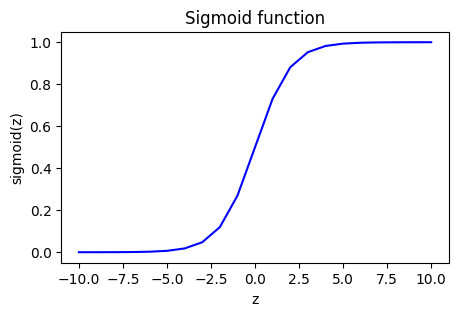

In [4]:
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')


In [9]:
def costfunc(w: int, b: int, x: np.ndarray, y: np.ndarray) -> float:
    m = x.shape[0]
    sum = 0
    for i in range(m):
        sum += (w*x[i] + b - y[i])**2
    return sum//(2*m)

def compute_gradient(x, y, w, b): 
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    for i in range(m):  
        f_wb = sigmoid(w * x[i] + b) 
        dj_db += f_wb - y[i] 
        dj_dw += (f_wb - y[i]) * x[i] 
    return dj_dw / m, dj_db / m

def gradient_descent(x, y, w_in, b_in, alpha, num_iters): 
    J_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w , b)     
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            
        if i<100000:
            J_history.append(costfunc(w, b, x, y))
    return w, b, J_history



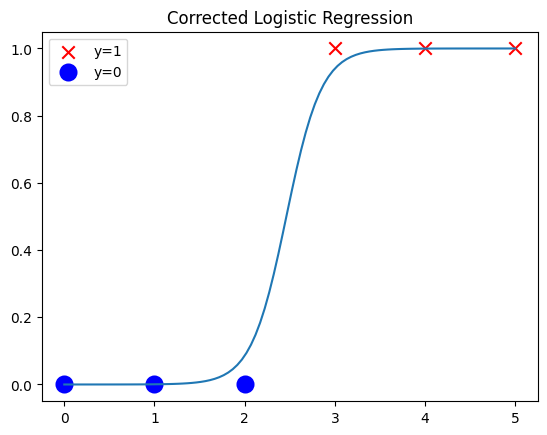

In [12]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])
pos = y_train == 1
neg = y_train == 0
w, b, j = gradient_descent(x_train, y_train, 0, 0, 0.01, 100000)
x_smooth = np.linspace(0, 5, 100)
g_z = sigmoid(w * x_smooth + b)
plt.plot(x_smooth, g_z)
plt.scatter(x_train[pos], y_train[pos], marker='x', s=80, c = 'red', label="y=1")
plt.scatter(x_train[neg], y_train[neg], marker='o', s=100, label="y=0", c='b', lw=3)
plt.legend()
plt.title("Corrected Logistic Regression")
plt.show()
